# 2025/26 Artificial Intelligence (U19967) - Lab on Supervised Learning
Adedayo Olowolayemo, Msc AFHEA

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  

## Two techniques
###  - Principal Component Analysis
###  - KMeans Clustering

![Iris Metadata](https://hub.2i2c.mybinder.org/user/profdee92-ai-rise-note-eaafk9cv/view/Iris%20Metadata.png)

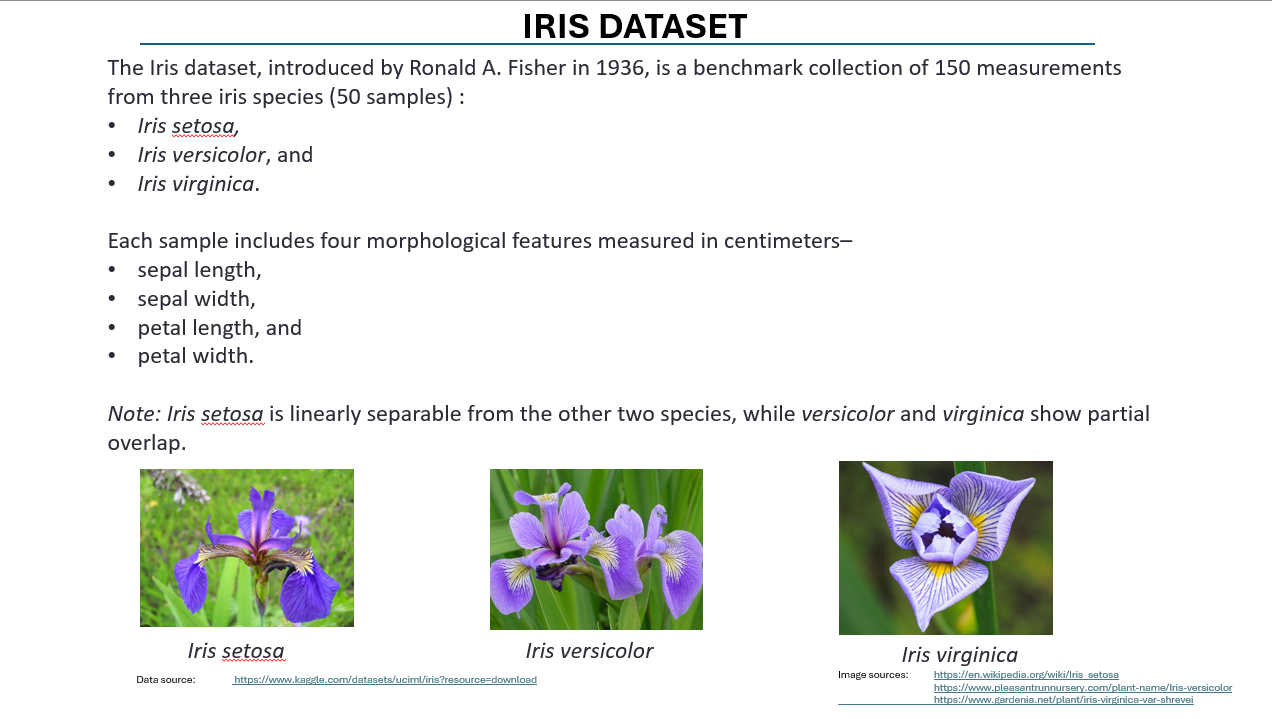

In [2]:
from IPython.display import Image, display
display(Image("Iris Metadata.png"))  

## Unsupervised ML Techniques - KMeans Clustering

### We import all dependecies

In [9]:
# STAGE 1: Setup

import os
os.environ["OMP_NUM_THREADS"] = "1"  # Suppress MKL warning on Windows

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Load data

In [10]:
# STAGE 2: Load Data & Show Original Table

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]  # petal length, petal width
feature_names = ['petal length (cm)', 'petal width (cm)']

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

print(" BEFORE STANDARDIZATION — First 5 rows:")
print(df.head().round(3))
print("\n" + "="*50 + "\n")


 BEFORE STANDARDIZATION — First 5 rows:
   petal length (cm)  petal width (cm) species
0                1.4               0.2  setosa
1                1.4               0.2  setosa
2                1.3               0.2  setosa
3                1.5               0.2  setosa
4                1.4               0.2  setosa




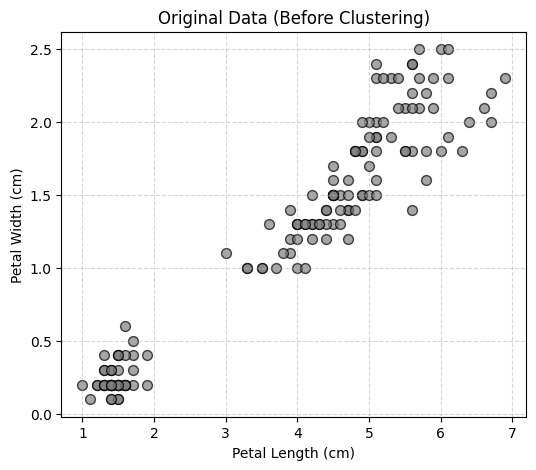

In [11]:
# STAGE 3: Plot Original Data (No Labels)

plt.figure(figsize=(6, 5))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'],
            c='gray', alpha=0.7, edgecolor='k', s=50)
plt.title('Original Data (Before Clustering)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [15]:
# STAGE 4: Standardize & Show Table

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=[f'{f} (scaled)' for f in feature_names])
print(" AFTER STANDARDIZATION — First 5 rows:")
print(df_scaled.head().round(3))
print("\n Verification: Mean ≈ 0, Std ≈ 1")
print("Means:", X_scaled.mean(axis=0).round(6))
print("Std devs:", X_scaled.std(axis=0).round(6))
print("\n" + "="*50 + "\n")

 AFTER STANDARDIZATION — First 5 rows:
   petal length (cm) (scaled)  petal width (cm) (scaled)
0                      -1.340                     -1.315
1                      -1.340                     -1.315
2                      -1.397                     -1.315
3                      -1.283                     -1.315
4                      -1.340                     -1.315

 Verification: Mean ≈ 0, Std ≈ 1
Means: [-0. -0.]
Std devs: [1. 1.]




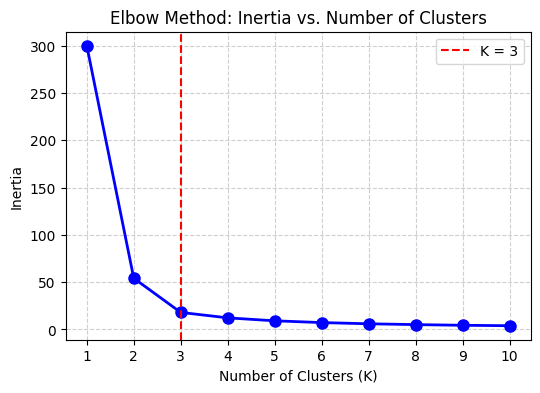

In [13]:
# STAGE 5: Elbow Method

K_range = range(1, 11)
inertias = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.title('Elbow Method: Inertia vs. Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### K-Means uses Euclidean distance. If one feature has a much larger scale (like petal length: 1-7 cm) than another (sepal width: 2-4 cm), it will  dominate the distance calculation - making other features irrelevant.

#### Standardization ensures:
####     All features have mean = 0, std = 1
####     No feature dominates due to scale
####     Clustering is based on relative shape, not absolute size


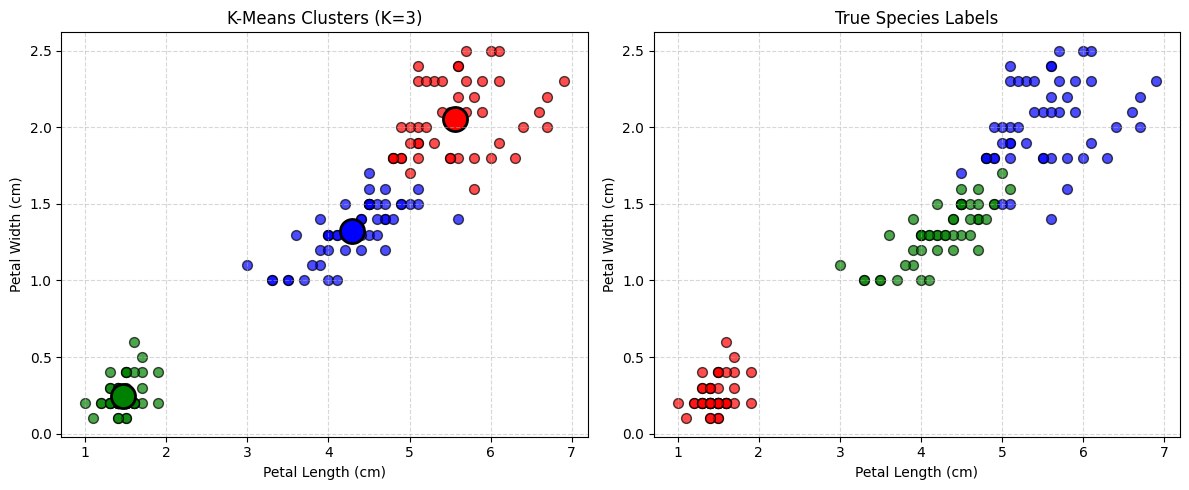

In [14]:
# STAGE 6: Apply K-Means (K=3) & Show Final Comparison

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)


true_colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# LEFT: K-Means Clusters
colors = ['red', 'green', 'blue']  # matches true_colors order due to reproducibility
for i in range(3):
    mask = y_kmeans == i
    axes[0].scatter(X[mask, 0], X[mask, 1],
                    c=colors[i], alpha=0.7, edgecolor='k', s=50)
    axes[0].scatter(centroids_orig[i, 0], centroids_orig[i, 1],
                    c=colors[i], s=300, marker='o', edgecolor='black', linewidth=2)
axes[0].set_title('K-Means Clusters (K=3)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# RIGHT: True Species Labels
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                    c=true_colors[species], alpha=0.7, edgecolor='k', s=50)
axes[1].set_title('True Species Labels')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Unsupervised ML Techniques - Principal Component Analysis (PCA)
 
 
 We will be using the popular Iris Dataset.
 
 But before we proceed, it is good to understand our dataset 


## Step 1: Load and Inspect Original Data

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Load data
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

## Step 2: Standardize the Features

In [12]:
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

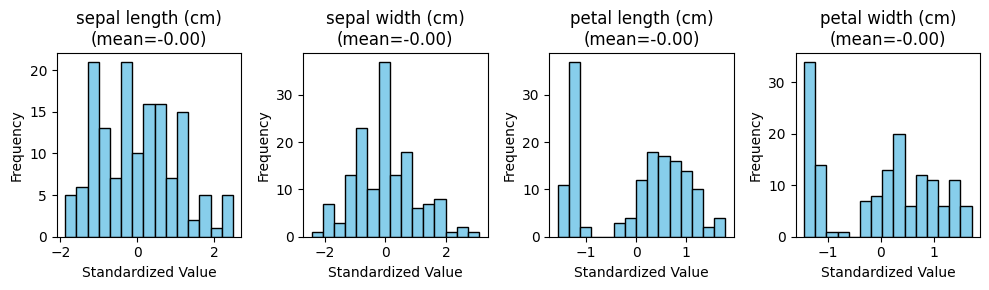

In [13]:

# Verify standardization
plt.figure(figsize=(10, 3))
for i, name in enumerate(feature_names):
    plt.subplot(1, 4, i+1)
    plt.hist(X_scaled[:, i], bins=15, color='skyblue', edgecolor='k')
    plt.title(f'{name}\n(mean={X_scaled[:,i].mean():.2f})')
    plt.xlabel('Standardized Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 3: Fit Full PCA and Show Scree Plot

In [14]:
from sklearn.decomposition import PCA

# Fit PCA with all components (n=4)
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


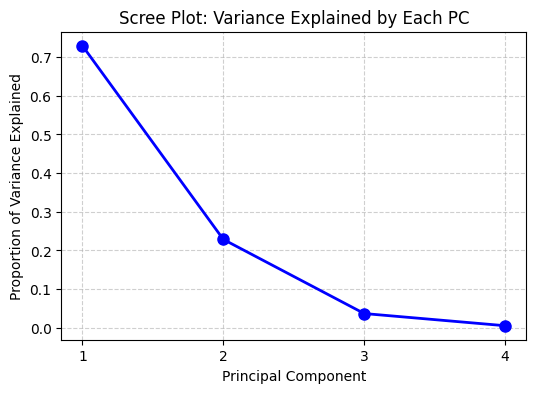

In [15]:
# Scree plot: variance per PC
plt.figure(figsize=(6, 4))
PCs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(PCs, pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.title('Scree Plot: Variance Explained by Each PC')

plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(PCs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Step 4: Cumulative Variance Explained

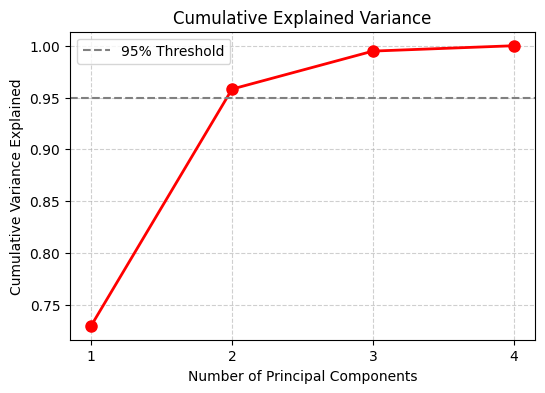

→ 2 PCs explain 95.8% of total variance.


In [16]:
# Cumulative variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(PCs, cumulative_var, 'ro-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')

plt.ylabel('Cumulative Variance Explained')
plt.xticks(PCs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print key insight
print(f"→ 2 PCs explain {cumulative_var[1]:.1%} of total variance.")

## Step 5: Project Data onto First 2 PCs

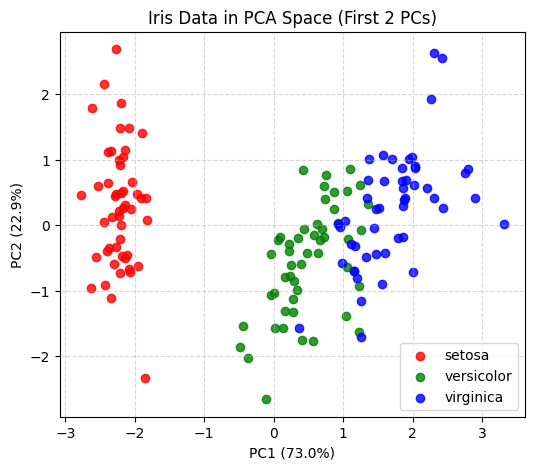

In [17]:

# Transform data to 2D

colors = ['red', 'green', 'blue']


X_pca = pca.transform(X_scaled)[:, :2]



# Plot PCA result
plt.figure(figsize=(6, 5))
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=color, label=target_names[i], alpha=0.8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Iris Data in PCA Space (First 2 PCs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()